# Evaluating LLM systems, with statistics

`compare_llms` brings mushin's seed-based significance testing to LLM/system
evaluation. You give it `systems` (callables `(inputs, seed) -> outputs`), a
`data` eval set, and a `metric`; it runs each system across seeds and reports
which differences are statistically real. Here both "systems" are fakes (no
network, no keys) whose per-seed noise stands in for `temperature > 0`.

In [ ]:
from __future__ import annotations

import random

from mushin.llm import compare_llms

A tiny even/odd classification eval set.

In [ ]:
data = [{"input": i, "reference": "even" if i % 2 == 0 else "odd"} for i in range(20)]


def exact_match(output: str, reference: str) -> float:
    return float(output.strip() == reference.strip())

Two fake systems: a strong one that occasionally slips, and a biased one that
leans "even". Each wires the trial `seed` to its randomness, so the per-seed
scores form a real sampling distribution.

In [ ]:
def strong(inputs, seed):
    rng = random.Random(seed)
    out = []
    for i in inputs:
        label = "even" if i % 2 == 0 else "odd"
        if rng.random() < 0.15:  # occasional slip
            label = "odd" if label == "even" else "even"
        out.append(label)
    return out


def biased(inputs, seed):
    rng = random.Random(1000 + seed)
    return ["even" if rng.random() < 0.85 else "odd" for _ in inputs]

Compare them across five seeds with Welch's t-test.

In [ ]:
result = compare_llms(
    systems={"strong": strong, "biased": biased},
    data=data,
    metric=exact_match,
    seeds=range(5),
    test="welch",
)
result.summary()

,method,metric,mean,ci_low,ci_high,significant_vs_ref
0,strong,score,0.88,0.767220,0.992780,
1,biased,score,0.49,0.387987,0.592013,*


The per-seed scores live in `result.data` (dims `method × seed`) — plot the
distribution each system produces across seeds.

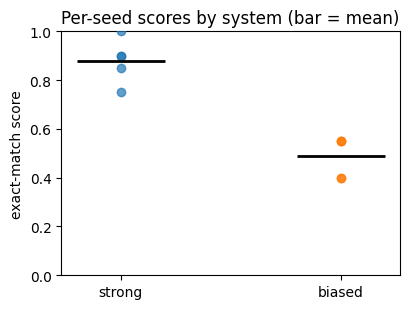

In [ ]:
import matplotlib.pyplot as plt

scores = result.data["score"]
methods = [str(m) for m in scores["method"].values]
fig, ax = plt.subplots(figsize=(4.2, 3.2))
for k, m in enumerate(methods):
    ys = scores.isel(method=k).values
    ax.scatter([k] * len(ys), ys, alpha=0.7, zorder=3)
    ax.hlines(ys.mean(), k - 0.2, k + 0.2, color="k", lw=2, zorder=4)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods)
ax.set_ylabel("exact-match score")
ax.set_ylim(0, 1)
ax.set_title("Per-seed scores by system (bar = mean)")
fig.tight_layout()
plt.show()

**See also**

- [LLM evaluation guide](../guides/llm.md) — real systems, hydra-zen configs,
  and the deterministic-system caveat.